This notebook is a copy of DBN3 except with slightly different changepoint values (from 500 to 120)

In [1]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Academics/Winter 2026/Bayes/Group Proj Personal/CMAPSSData/'

Mounted at /content/drive


In [2]:
!pip install filterpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=960c966376dbfce28d3e5770ef651312cc1cc87212b99a5e46be6dd277683543
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


# Mark I

In [ ]:
import pandas as pd
import numpy as np
from filterpy.kalman import UnscentedKalmanFilter, MerweScaledSigmaPoints

def fx(state, dt, u_t=None):
    return np.array([state[0] - 0.005 * dt])

def hx(state, u_t=None):
    return np.array([state[0], state[0]])

def enforce_positive_definite(matrix, jitter=1e-6):
    matrix = (matrix + matrix.T) / 2.0
    matrix += np.eye(matrix.shape[0]) * jitter
    return matrix

def update_noise_matrices(smoothed_states, measurements, u_ts, dt, old_Q, old_R, alpha=0.1):
    N = len(smoothed_states)

    measurement_residuals = []
    for k in range(N):
        expected_z = hx(smoothed_states[k], u_t=u_ts[k])
        measurement_residuals.append(measurements[k] - expected_z)

    measurement_residuals = np.array(measurement_residuals)
    empirical_R = np.cov(measurement_residuals.T)

    process_residuals = []
    for k in range(1, N):
        expected_x = fx(smoothed_states[k-1], dt, u_t=u_ts[k])
        process_residuals.append(smoothed_states[k] - expected_x)

    process_residuals = np.array(process_residuals)
    empirical_Q = np.cov(process_residuals.T)

    if empirical_Q.ndim == 0:
        empirical_Q = np.array([[empirical_Q.item()]])

    new_Q = (1 - alpha) * old_Q + alpha * empirical_Q
    new_R = (1 - alpha) * old_R + alpha * empirical_R

    return enforce_positive_definite(new_Q), enforce_positive_definite(new_R)

columns = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv(path + 'train_FD001.txt', sep=r'\s+', header=None, names=columns)

for col in ['sensor_2', 'sensor_3', 'op_setting_1', 'op_setting_2', 'op_setting_3']:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min() + 1e-8)

dt = 1.0
sigmas = MerweScaledSigmaPoints(n=1, alpha=0.1, beta=2., kappa=1.)
ukf = UnscentedKalmanFilter(dim_x=1, dim_z=2, dt=dt, fx=fx, hx=hx, points=sigmas)

ukf.R = np.diag([0.05, 0.05])
ukf.Q = np.diag([0.001])

epochs = 15
tolerance = 1e-5

for epoch in range(epochs):
    all_smoothed_states = []
    all_measurements = []
    all_uts = []

    for engine_id in df['engine_id'].unique()[:5]:
        engine_data = df[df['engine_id'] == engine_id]

        ukf.x = np.array([1.0])
        ukf.P = np.eye(1) * 0.1

        means = []
        covariances = []
        measurements = []
        u_ts = []

        for index, row in engine_data.iterrows():
            u_t = np.array([row['op_setting_1'], row['op_setting_2'], row['op_setting_3']])
            z_t = np.array([row['sensor_2'], row['sensor_3']])

            ukf.predict(u_t=u_t)
            ukf.update(z_t, u_t=u_t)

            ukf.P = enforce_positive_definite(ukf.P)

            means.append(ukf.x.copy())
            covariances.append(ukf.P.copy())
            measurements.append(z_t)
            u_ts.append(u_t)

        means = np.array(means)
        covariances = np.array(covariances)

        smoothed_means, smoothed_covariances, smoother_gains = ukf.rts_smoother(means, covariances)

        all_smoothed_states.extend(smoothed_means)
        all_measurements.extend(measurements)
        all_uts.extend(u_ts)

    new_Q, new_R = update_noise_matrices(all_smoothed_states, all_measurements, all_uts, dt, ukf.Q, ukf.R, alpha=0.2)

    q_diff = np.linalg.norm(ukf.Q - new_Q)
    r_diff = np.linalg.norm(ukf.R - new_R)

    ukf.Q = new_Q
    ukf.R = new_R

    print(f"Epoch {epoch+1} | Q diff: {q_diff:.6f} | R diff: {r_diff:.6f}")

    if q_diff < tolerance and r_diff < tolerance:
        break

Epoch 1 | Q diff: 0.000115 | R diff: 0.011969
Epoch 2 | Q diff: 0.000089 | R diff: 0.009583
Epoch 3 | Q diff: 0.000068 | R diff: 0.007675
Epoch 4 | Q diff: 0.000051 | R diff: 0.006149
Epoch 5 | Q diff: 0.000038 | R diff: 0.004929
Epoch 6 | Q diff: 0.000027 | R diff: 0.003954
Epoch 7 | Q diff: 0.000019 | R diff: 0.003174
Epoch 8 | Q diff: 0.000012 | R diff: 0.002550
Epoch 9 | Q diff: 0.000007 | R diff: 0.002051
Epoch 10 | Q diff: 0.000003 | R diff: 0.001651
Epoch 11 | Q diff: 0.000000 | R diff: 0.001332
Epoch 12 | Q diff: 0.000002 | R diff: 0.001076
Epoch 13 | Q diff: 0.000004 | R diff: 0.000870
Epoch 14 | Q diff: 0.000005 | R diff: 0.000705
Epoch 15 | Q diff: 0.000006 | R diff: 0.000573


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

columns = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
test_df = pd.read_csv(path + 'test_FD001.txt', sep=r'\s+', header=None, names=columns)
true_rul_df = pd.read_csv(path + 'RUL_FD001.txt', sep=r'\s+', header=None, names=['true_rul'])

for col in ['sensor_2', 'sensor_3', 'op_setting_1', 'op_setting_2', 'op_setting_3']:
    test_df[col] = (test_df[col] - test_df[col].min()) / (test_df[col].max() - test_df[col].min() + 1e-8)

predicted_ruls = []
true_ruls = true_rul_df['true_rul'].tolist()

for engine_id in test_df['engine_id'].unique():
    engine_data = test_df[test_df['engine_id'] == engine_id]

    ukf.x = np.array([1.0])
    ukf.P = np.eye(1) * 0.1

    for index, row in engine_data.iterrows():
        u_t = np.array([row['op_setting_1'], row['op_setting_2'], row['op_setting_3']])
        z_t = np.array([row['sensor_2'], row['sensor_3']])

        ukf.predict(u_t=u_t)
        ukf.update(z_t, u_t=u_t)

    predicted_rul = 0
    simulated_state = ukf.x.copy()
    default_u_t = np.array([0.0, 0.0, 0.0])

    while simulated_state[0] > 0.2 and predicted_rul < 500: #increased "failure threshold" to 0.2 from 0.0
        simulated_state = fx(simulated_state, dt=1.0, u_t=default_u_t)
        predicted_rul += 1

    predicted_ruls.append(predicted_rul)

rmse = np.sqrt(mean_squared_error(true_ruls, predicted_ruls))

cmapss_score = 0.0
for y_true, y_pred in zip(true_ruls, predicted_ruls):
    d = y_pred - y_true
    if d < 0:
        cmapss_score += np.exp(-d / 13.0) - 1.0
    else:
        cmapss_score += np.exp(d / 10.0) - 1.0

print(f"Test RMSE: {rmse:.2f}")
print(f"Test CMAPSS Score: {cmapss_score:.2f}")

Test RMSE: 62.22
Test CMAPSS Score: 275779.63


In [ ]:
import pandas as pd
import numpy as np

results_df = pd.DataFrame({
    'Engine_ID': test_df['engine_id'].unique(),
    'True_RUL': true_ruls,
    'Predicted_RUL': predicted_ruls
})

results_df['Error'] = results_df['Predicted_RUL'] - results_df['True_RUL']

def calculate_individual_penalty(error):
    if error < 0:
        return np.exp(-error / 13.0) - 1.0
    else:
        return np.exp(error / 10.0) - 1.0

results_df['Penalty'] = results_df['Error'].apply(calculate_individual_penalty)

results_df = results_df.sort_values(by='Penalty', ascending=False)

print(results_df.head(15).to_string(index=False))

 Engine_ID  True_RUL  Predicted_RUL  Error      Penalty
        68         8            115    107 44354.855130
        34         7            113    106 40133.837431
        76        10            115    105 36314.502674
        81         8            109    101 24342.009424
        31         8            108    100 22025.465795
        35        11            110     99 19929.370438
        42        10            102     92  9896.129059
        20        16            108     92  9896.129059
        39       142             23   -119  9449.719488
        66        14            105     91  8954.292703
        82         9             99     90  8102.083928
        36        19            106     87  6001.912217
        56        15            100     85  4913.768840
        49        21            104     83  4022.872394
        92        20            102     82  3639.950307


In [ ]:
import pandas as pd
import numpy as np

columns = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
train_df = pd.read_csv(path + 'train_FD001.txt', sep=r'\s+', header=None, names=columns)

def add_true_rul(df):
    max_cycle = df.groupby('engine_id')['cycle'].max()
    merged = df.merge(max_cycle.to_frame(name='max_cycle'), left_on='engine_id', right_index=True)
    merged['RUL'] = merged['max_cycle'] - merged['cycle']
    merged = merged.drop('max_cycle', axis=1)
    return merged

train_df = add_true_rul(train_df)

# Identify and drop constant columns to avoid RuntimeWarning (division by zero)
sensor_columns = [f'sensor_{i}' for i in range(1, 22)]
# Check std deviation; if 0, it's constant.
non_constant_sensors = [col for col in sensor_columns if train_df[col].std() > 1e-10]

correlations = {}

for col in non_constant_sensors:
    corr = train_df[col].corr(train_df['RUL'])
    correlations[col] = corr

corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation_with_RUL'])
corr_df['Absolute_Correlation'] = corr_df['Correlation_with_RUL'].abs()
corr_df = corr_df.sort_values(by='Absolute_Correlation', ascending=False)

print(corr_df)

           Correlation_with_RUL  Absolute_Correlation
sensor_11             -0.696228              0.696228
sensor_4              -0.678948              0.678948
sensor_12              0.671983              0.671983
sensor_7               0.657223              0.657223
sensor_15             -0.642667              0.642667
sensor_21              0.635662              0.635662
sensor_20              0.629428              0.629428
sensor_2              -0.606484              0.606484
sensor_17             -0.606154              0.606154
sensor_3              -0.584520              0.584520
sensor_8              -0.563968              0.563968
sensor_13             -0.562569              0.562569
sensor_9              -0.390102              0.390102
sensor_14             -0.306769              0.306769
sensor_6              -0.128348              0.128348


# Mark II
(PCA)

In [3]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from filterpy.kalman import UnscentedKalmanFilter, MerweScaledSigmaPoints

columns = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
train_df_raw = pd.read_csv(path + 'train_FD001.txt', sep=r'\s+', header=None, names=columns)

valid_sensors = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]

sensor_stats = {}
for col in valid_sensors:
    min_val = train_df_raw[col].min()
    max_val = train_df_raw[col].max()
    sensor_stats[col] = {'min': min_val, 'max': max_val}
    train_df_raw[col] = (train_df_raw[col] - min_val) / (max_val - min_val + 1e-8)

pca = PCA(n_components=2)
train_pcs = pca.fit_transform(train_df_raw[valid_sensors])

def get_rul(df):
    max_cycle = df.groupby('engine_id')['cycle'].max()
    merged = df.merge(max_cycle.to_frame(name='max_cycle'), left_on='engine_id', right_index=True)
    return merged['max_cycle'] - merged['cycle']

train_rul = get_rul(train_df_raw)

pc_stats = {}
for i, pc_name in enumerate(['pc_1', 'pc_2']):
    pc_values = train_pcs[:, i]
    corr = np.corrcoef(pc_values, train_rul)[0, 1]
    flip = -1.0 if corr < 0 else 1.0
    pc_values = pc_values * flip
    min_val = pc_values.min()
    max_val = pc_values.max()
    pc_stats[pc_name] = {'flip': flip, 'min': min_val, 'max': max_val}

train_df_raw['pc_1'] = train_pcs[:, 0] * pc_stats['pc_1']['flip']
train_df_raw['pc_2'] = train_pcs[:, 1] * pc_stats['pc_2']['flip']

for pc in ['pc_1', 'pc_2']:
    min_val = pc_stats[pc]['min']
    max_val = pc_stats[pc]['max']
    train_df_raw[pc] = (train_df_raw[pc] - min_val) / (max_val - min_val + 1e-8)

baselines = [0.001, 0.002, 0.003, 0.004]
curvatures = [2.0, 3.0, 3.5, 4.0, 4.5]

best_score = float('inf')
best_params = {}

validation_engines = range(81, 91)
cutoff_rul = 40

def hx(state, u_t=None):
    return np.array([state[0], state[0]])

sigmas = MerweScaledSigmaPoints(n=1, alpha=0.1, beta=2., kappa=1.)

for base in baselines:
    for curve in curvatures:

        def fx_search(state, dt, u_t=None):
            exponent = np.clip(curve * (1.0 - state[0]), a_min=-20.0, a_max=10.0)
            decay_rate = base * np.exp(exponent)
            return np.array([state[0] - decay_rate * dt])

        current_cmapss_score = 0.0

        for engine_id in validation_engines:
            engine_data = train_df_raw[train_df_raw['engine_id'] == engine_id].copy()
            max_cycle = engine_data['cycle'].max()
            cutoff_cycle = max_cycle - cutoff_rul

            truncated_data = engine_data[engine_data['cycle'] <= cutoff_cycle]

            test_ukf = UnscentedKalmanFilter(dim_x=1, dim_z=2, dt=1.0, fx=fx_search, hx=hx, points=sigmas)
            test_ukf.R = np.diag([0.05, 0.05])
            test_ukf.Q = np.diag([0.001])
            test_ukf.x = np.array([1.0])
            test_ukf.P = np.eye(1) * 0.1

            for index, row in truncated_data.iterrows():
                u_t = np.array([row['op_setting_1'], row['op_setting_2'], row['op_setting_3']])
                z_t = np.array([row['pc_1'], row['pc_2']])
                test_ukf.predict(u_t=u_t)
                test_ukf.update(z_t, u_t=u_t)

            predicted_rul = 0
            simulated_state = test_ukf.x.copy()
            default_u_t = np.array([0.0, 0.0, 0.0])

            while simulated_state[0] > 0.2 and predicted_rul < 500:
                simulated_state = fx_search(simulated_state, dt=1.0, u_t=default_u_t)
                predicted_rul += 1

            d = predicted_rul - cutoff_rul
            if d < 0:
                current_cmapss_score += np.exp(-d / 13.0) - 1.0
            else:
                current_cmapss_score += np.exp(d / 10.0) - 1.0

        print(f"Base: {base}, Curve: {curve} | Score: {current_cmapss_score:.2f}")

        if current_cmapss_score < best_score:
            best_score = current_cmapss_score
            best_params = {'baseline': base, 'curvature': curve}

print(f"\nOptimal Parameters: Baseline = {best_params['baseline']}, Curvature = {best_params['curvature']}")
print(f"Minimum Validation Score: {best_score:.2f}")

Base: 0.001, Curve: 2.0 | Score: 143011.06
Base: 0.001, Curve: 3.0 | Score: 270.02
Base: 0.001, Curve: 3.5 | Score: 34.36
Base: 0.001, Curve: 4.0 | Score: 14.13


KeyboardInterrupt: 

In [4]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from filterpy.kalman import UnscentedKalmanFilter, MerweScaledSigmaPoints

import numpy as np

def fx(state, dt, u_t=None):
    exponent = np.clip(2 * (1.0 - state[0]), a_min=-20.0, a_max=10.0)
    decay_rate = 0.003 * np.exp(exponent)
    return np.array([state[0] - decay_rate * dt])

def hx(state, u_t=None):
    return np.array([state[0], state[0]])

def enforce_positive_definite(matrix, jitter=1e-6):
    matrix = (matrix + matrix.T) / 2.0
    matrix += np.eye(matrix.shape[0]) * jitter
    return matrix

def update_noise_matrices(smoothed_states, measurements, u_ts, dt, old_Q, old_R, alpha=0.1):
    N = len(smoothed_states)

    measurement_residuals = []
    for k in range(N):
        expected_z = hx(smoothed_states[k], u_t=u_ts[k])
        measurement_residuals.append(measurements[k] - expected_z)

    measurement_residuals = np.array(measurement_residuals)
    empirical_R = np.cov(measurement_residuals.T)

    process_residuals = []
    for k in range(1, N):
        expected_x = fx(smoothed_states[k-1], dt, u_t=u_ts[k])
        process_residuals.append(smoothed_states[k] - expected_x)

    process_residuals = np.array(process_residuals)
    empirical_Q = np.cov(process_residuals.T)

    if empirical_Q.ndim == 0:
        empirical_Q = np.array([[empirical_Q.item()]])

    new_Q = (1 - alpha) * old_Q + alpha * empirical_Q
    new_R = (1 - alpha) * old_R + alpha * empirical_R

    return enforce_positive_definite(new_Q), enforce_positive_definite(new_R)

columns = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
train_df = pd.read_csv(path + 'train_FD001.txt', sep=r'\s+', header=None, names=columns)

valid_sensors = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]

for col in valid_sensors:
    min_val = train_df[col].min()
    max_val = train_df[col].max()
    train_df[col] = (train_df[col] - min_val) / (max_val - min_val + 1e-8)

pca = PCA(n_components=2)
train_pcs = pca.fit_transform(train_df[valid_sensors])

train_df['pc_1'] = train_pcs[:, 0]
train_df['pc_2'] = train_pcs[:, 1]

def add_true_rul(df):
    max_cycle = df.groupby('engine_id')['cycle'].max()
    merged = df.merge(max_cycle.to_frame(name='max_cycle'), left_on='engine_id', right_index=True)
    merged['RUL'] = merged['max_cycle'] - merged['cycle']
    return merged.drop('max_cycle', axis=1)

train_df_with_rul = add_true_rul(train_df.copy())

for pc in ['pc_1', 'pc_2']:
    corr = train_df_with_rul[pc].corr(train_df_with_rul['RUL'])
    if corr < 0:
        train_df[pc] = -train_df[pc]

for col in ['pc_1', 'pc_2']:
    min_val = train_df[col].min()
    max_val = train_df[col].max()
    train_df[col] = (train_df[col] - min_val) / (max_val - min_val + 1e-8)

dt = 1.0
sigmas = MerweScaledSigmaPoints(n=1, alpha=0.1, beta=2., kappa=1.)
ukf = UnscentedKalmanFilter(dim_x=1, dim_z=2, dt=dt, fx=fx, hx=hx, points=sigmas)

ukf.R = np.diag([0.05, 0.05])
ukf.Q = np.diag([0.001])

epochs = 15
tolerance = 1e-5

for epoch in range(epochs):
    all_smoothed_states = []
    all_measurements = []
    all_uts = []

    for engine_id in train_df['engine_id'].unique()[:5]:
        engine_data = train_df[train_df['engine_id'] == engine_id]

        ukf.x = np.array([1.0])
        ukf.P = np.eye(1) * 0.1

        means = []
        covariances = []
        measurements = []
        u_ts = []

        for index, row in engine_data.iterrows():
            u_t = np.array([row['op_setting_1'], row['op_setting_2'], row['op_setting_3']])
            z_t = np.array([row['pc_1'], row['pc_2']])

            ukf.predict(u_t=u_t)
            ukf.update(z_t, u_t=u_t)

            ukf.P = enforce_positive_definite(ukf.P)

            means.append(ukf.x.copy())
            covariances.append(ukf.P.copy())
            measurements.append(z_t)
            u_ts.append(u_t)

        means = np.array(means)
        covariances = np.array(covariances)

        smoothed_means, smoothed_covariances, smoother_gains = ukf.rts_smoother(means, covariances)

        all_smoothed_states.extend(smoothed_means)
        all_measurements.extend(measurements)
        all_uts.extend(u_ts)

    new_Q, new_R = update_noise_matrices(all_smoothed_states, all_measurements, all_uts, dt, ukf.Q, ukf.R, alpha=0.2)

    q_diff = np.linalg.norm(ukf.Q - new_Q)
    r_diff = np.linalg.norm(ukf.R - new_R)

    ukf.Q = new_Q
    ukf.R = new_R

    print(f"Epoch {epoch+1} | Q diff: {q_diff:.6f} | R diff: {r_diff:.6f}")

    if q_diff < tolerance and r_diff < tolerance:
        break

Epoch 1 | Q diff: 0.000023 | R diff: 0.012010
Epoch 2 | Q diff: 0.000016 | R diff: 0.009612
Epoch 3 | Q diff: 0.000010 | R diff: 0.007693
Epoch 4 | Q diff: 0.000006 | R diff: 0.006158
Epoch 5 | Q diff: 0.000003 | R diff: 0.004929
Epoch 6 | Q diff: 0.000001 | R diff: 0.003946
Epoch 7 | Q diff: 0.000001 | R diff: 0.003160
Epoch 8 | Q diff: 0.000001 | R diff: 0.002531
Epoch 9 | Q diff: 0.000002 | R diff: 0.002028
Epoch 10 | Q diff: 0.000002 | R diff: 0.001626
Epoch 11 | Q diff: 0.000002 | R diff: 0.001304
Epoch 12 | Q diff: 0.000002 | R diff: 0.001047
Epoch 13 | Q diff: 0.000002 | R diff: 0.000841
Epoch 14 | Q diff: 0.000001 | R diff: 0.000676
Epoch 15 | Q diff: 0.000001 | R diff: 0.000544


In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA

CHANGEPOINT = 112

def fx(state, dt, u_t=None):
    exponent = np.clip(2 * (1.0 - state[0]), a_min=-20.0, a_max=10.0)
    decay_rate = 0.003 * np.exp(exponent)
    return np.array([state[0] - decay_rate * dt])

def hx(state, u_t=None):
    return np.array([state[0], state[0]])

# --- Preprocessing to replicate training transformation ---
# 1. Re-load training data to recover transformation statistics
columns = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
train_df_raw = pd.read_csv(path + 'train_FD001.txt', sep=r'\s+', header=None, names=columns)

valid_sensors = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]

sensor_stats = {}
for col in valid_sensors:
    min_val = train_df_raw[col].min()
    max_val = train_df_raw[col].max()
    sensor_stats[col] = {'min': min_val, 'max': max_val}
    train_df_raw[col] = (train_df_raw[col] - min_val) / (max_val - min_val + 1e-8)

pca = PCA(n_components=2)
train_pcs = pca.fit_transform(train_df_raw[valid_sensors])

# Helper for RUL
def get_rul(df):
    max_cycle = df.groupby('engine_id')['cycle'].max()
    merged = df.merge(max_cycle.to_frame(name='max_cycle'), left_on='engine_id', right_index=True)
    return merged['max_cycle'] - merged['cycle']

train_rul = get_rul(train_df_raw)

pc_stats = {}
for i, pc_name in enumerate(['pc_1', 'pc_2']):
    pc_values = train_pcs[:, i]
    # Check correlation for flip
    corr = np.corrcoef(pc_values, train_rul)[0, 1]
    flip = -1.0 if corr < 0 else 1.0
    pc_values = pc_values * flip

    # Min/Max for normalization
    min_val = pc_values.min()
    max_val = pc_values.max()
    pc_stats[pc_name] = {'flip': flip, 'min': min_val, 'max': max_val}

# 2. Load and Transform Test Data
test_df = pd.read_csv(path + 'test_FD001.txt', sep=r'\s+', header=None, names=columns)
true_rul_df = pd.read_csv(path + 'RUL_FD001.txt', sep=r'\s+', header=None, names=['true_rul'])

# Normalize sensors
for col in valid_sensors:
    stats = sensor_stats[col]
    test_df[col] = (test_df[col] - stats['min']) / (stats['max'] - stats['min'] + 1e-8)

# PCA
test_pcs = pca.transform(test_df[valid_sensors])
test_df['pc_1'] = test_pcs[:, 0]
test_df['pc_2'] = test_pcs[:, 1]

# Normalize PCs
for pc in ['pc_1', 'pc_2']:
    stats = pc_stats[pc]
    test_df[pc] = test_df[pc] * stats['flip']
    test_df[pc] = (test_df[pc] - stats['min']) / (stats['max'] - stats['min'] + 1e-8)

predicted_ruls = []
true_ruls = true_rul_df['true_rul'].tolist()

for engine_id in test_df['engine_id'].unique():
    engine_data = test_df[test_df['engine_id'] == engine_id]

    ukf.x = np.array([1.0])
    ukf.P = np.eye(1) * 0.1

    for index, row in engine_data.iterrows():
        u_t = np.array([row['op_setting_1'], row['op_setting_2'], row['op_setting_3']])
        z_t = np.array([row['pc_1'], row['pc_2']])

        ukf.predict(u_t=u_t)
        ukf.update(z_t, u_t=u_t)

    predicted_rul = 0
    simulated_state = ukf.x.copy()
    default_u_t = np.array([0.0, 0.0, 0.0])



    while simulated_state[0] > 0.0 and predicted_rul < CHANGEPOINT:
        simulated_state = fx(simulated_state, dt=1.0, u_t=default_u_t)
        predicted_rul += 1

    predicted_ruls.append(predicted_rul)

rmse = np.sqrt(mean_squared_error(true_ruls, predicted_ruls))

cmapss_score = 0.0
for y_true, y_pred in zip(true_ruls, predicted_ruls):
    d = y_pred - y_true
    if d < 0:
        cmapss_score += np.exp(-d / 13.0) - 1.0
    else:
        cmapss_score += np.exp(d / 10.0) - 1.0

print(f"Final Test RMSE: {rmse:.2f}")
print(f"Final Test CMAPSS Score: {cmapss_score:.2f}")

Final Test RMSE: 35.85
Final Test CMAPSS Score: 3311.77


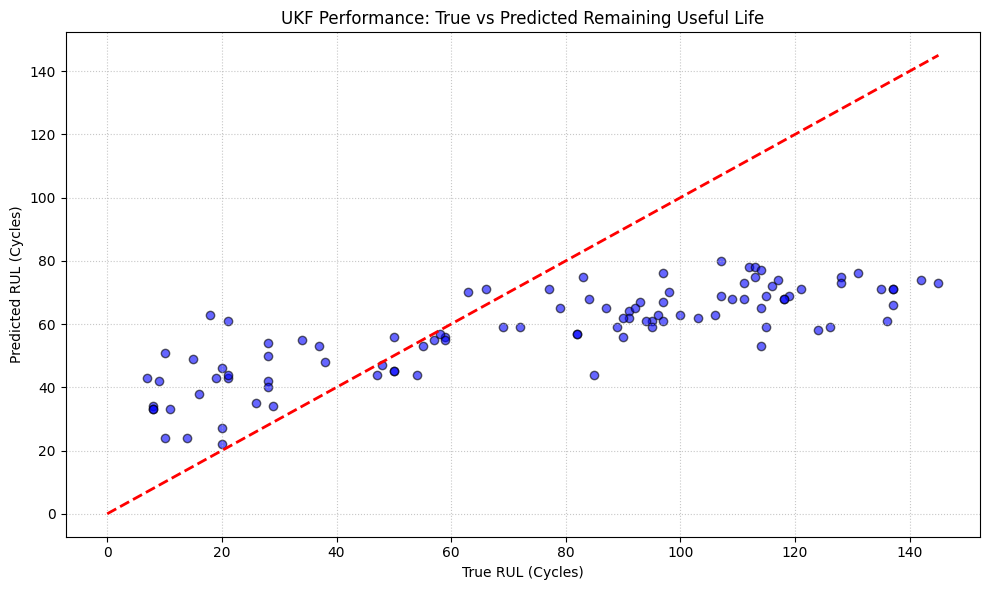

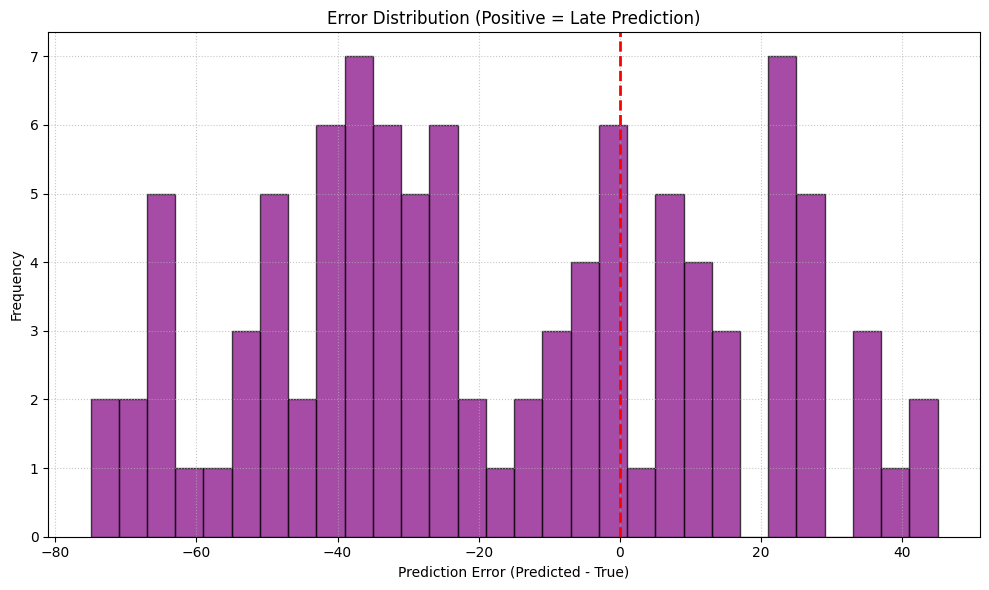

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(true_ruls, predicted_ruls, alpha=0.6, color='blue', edgecolor='k')

max_rul = max(max(true_ruls), max(predicted_ruls))
plt.plot([0, max_rul], [0, max_rul], color='red', linestyle='--', linewidth=2)

plt.xlabel('True RUL (Cycles)')
plt.ylabel('Predicted RUL (Cycles)')
plt.title('UKF Performance: True vs Predicted Remaining Useful Life')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

errors = np.array(predicted_ruls) - np.array(true_ruls)

plt.figure(figsize=(10, 6))
plt.hist(errors, bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Prediction Error (Predicted - True)')
plt.ylabel('Frequency')
plt.title('Error Distribution (Positive = Late Prediction)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

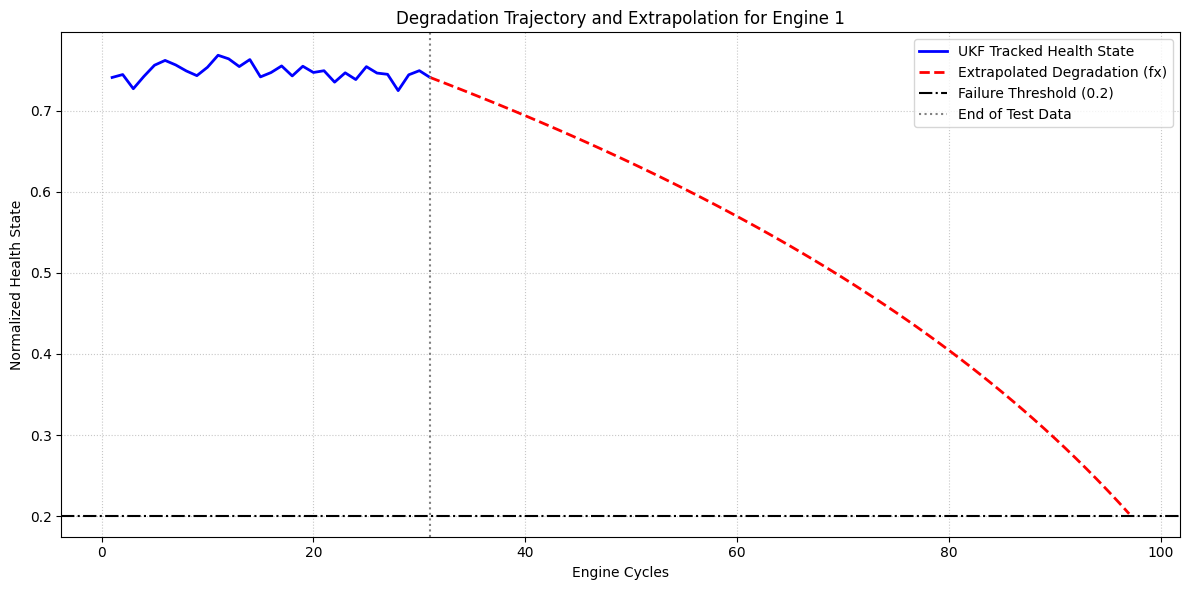

In [9]:
import matplotlib.pyplot as plt
import numpy as np

engine_id_to_plot = test_df['engine_id'].unique()[0]
engine_data = test_df[test_df['engine_id'] == engine_id_to_plot]

tracked_states = []
extrapolated_states = []

ukf.x = np.array([1.0])
ukf.P = np.eye(1) * 0.1

for index, row in engine_data.iterrows():
    u_t = np.array([row['op_setting_1'], row['op_setting_2'], row['op_setting_3']])
    z_t = np.array([row['pc_1'], row['pc_2']])

    ukf.predict(u_t=u_t)
    ukf.update(z_t, u_t=u_t)
    tracked_states.append(ukf.x[0])

simulated_state = ukf.x.copy()
default_u_t = np.array([0.0, 0.0, 0.0])
predicted_rul = 0

while simulated_state[0] > 0.2 and predicted_rul < 500:
    simulated_state = fx(simulated_state, dt=1.0, u_t=default_u_t)
    extrapolated_states.append(simulated_state[0])
    predicted_rul += 1

observed_cycles = range(1, len(tracked_states) + 1)
extrapolated_cycles = range(len(tracked_states), len(tracked_states) + len(extrapolated_states))

plt.figure(figsize=(12, 6))
plt.plot(observed_cycles, tracked_states, label='UKF Tracked Health State', color='blue', linewidth=2)

if extrapolated_states:
    plt.plot(extrapolated_cycles, [tracked_states[-1]] + extrapolated_states[:-1],
             label='Extrapolated Degradation (fx)', color='red', linestyle='--', linewidth=2)

plt.axhline(0.2, color='black', linestyle='-.', label='Failure Threshold (0.2)')
plt.axvline(len(tracked_states), color='gray', linestyle=':', label='End of Test Data')

plt.xlabel('Engine Cycles')
plt.ylabel('Normalized Health State')
plt.title(f'Degradation Trajectory and Extrapolation for Engine {engine_id_to_plot}')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
from sklearn.metrics import mean_squared_error
import pandas as pd

# --- 1. Prepare Training Data (Apply same transforms as Test) ---
# Reload raw data to ensure no double-normalization occurs
columns = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
train_eval = pd.read_csv(path + 'train_FD001.txt', sep=r'\s+', header=None, names=columns)

# Normalize sensors
for col in valid_sensors:
    stats = sensor_stats[col]
    train_eval[col] = (train_eval[col] - stats['min']) / (stats['max'] - stats['min'] + 1e-8)

# PCA Transform
train_eval_pcs = pca.transform(train_eval[valid_sensors])
train_eval['pc_1'] = train_eval_pcs[:, 0]
train_eval['pc_2'] = train_eval_pcs[:, 1]

# Normalize PCs
for pc in ['pc_1', 'pc_2']:
    stats = pc_stats[pc]
    train_eval[pc] = train_eval[pc] * stats['flip']
    train_eval[pc] = (train_eval[pc] - stats['min']) / (stats['max'] - stats['min'] + 1e-8)

# --- 2. Predict on Randomly Truncated Training Data ---
# Instead of a fixed 40, we pick a random point in the engine's life to stop feeding data
train_predicted_ruls = []
train_true_ruls = []

print(f"Evaluating on Training Set with Random Truncation Points...")

np.random.seed(42) # Ensure reproducibility

for engine_id in train_eval['engine_id'].unique():
    engine_data = train_eval[train_eval['engine_id'] == engine_id]
    max_cycle = engine_data['cycle'].max()

    # Ensure we have enough data to settle the filter (e.g., at least 30 cycles)
    if max_cycle <= 30:
        continue

    # Randomly select a cutoff cycle between 20 and the end of life
    cutoff_cycle = np.random.randint(20, max_cycle)

    # The True RUL is the remaining cycles after the cutoff
    true_rul_at_cutoff = max_cycle - cutoff_cycle

    truncated_data = engine_data[engine_data['cycle'] <= cutoff_cycle]

    # Reset Filter
    ukf.x = np.array([1.0])
    ukf.P = np.eye(1) * 0.1

    # Process observed data
    for index, row in truncated_data.iterrows():
        u_t = np.array([row['op_setting_1'], row['op_setting_2'], row['op_setting_3']])
        z_t = np.array([row['pc_1'], row['pc_2']])

        ukf.predict(u_t=u_t)
        ukf.update(z_t, u_t=u_t)

    # Extrapolate / Predict
    predicted_rul = 0
    simulated_state = ukf.x.copy()
    default_u_t = np.array([0.0, 0.0, 0.0])

    while simulated_state[0] > 0.0 and predicted_rul < 500:
        simulated_state = fx(simulated_state, dt=1.0, u_t=default_u_t)
        predicted_rul += 1

    train_predicted_ruls.append(predicted_rul)
    train_true_ruls.append(true_rul_at_cutoff)

# --- 3. Calculate Metrics ---
rmse_train = np.sqrt(mean_squared_error(train_true_ruls, train_predicted_ruls))

cmapss_score_train = 0.0
for y_true, y_pred in zip(train_true_ruls, train_predicted_ruls):
    d = y_pred - y_true
    if d < 0:
        cmapss_score_train += np.exp(-d / 13.0) - 1.0
    else:
        cmapss_score_train += np.exp(d / 10.0) - 1.0

print(f"Training RMSE: {rmse_train:.2f}")
print(f"Training CMAPSS Score: {cmapss_score_train:.2f}")

Evaluating on Training Set with Random Truncation Points...
Training RMSE: 63.60
Training CMAPSS Score: 90500546.75


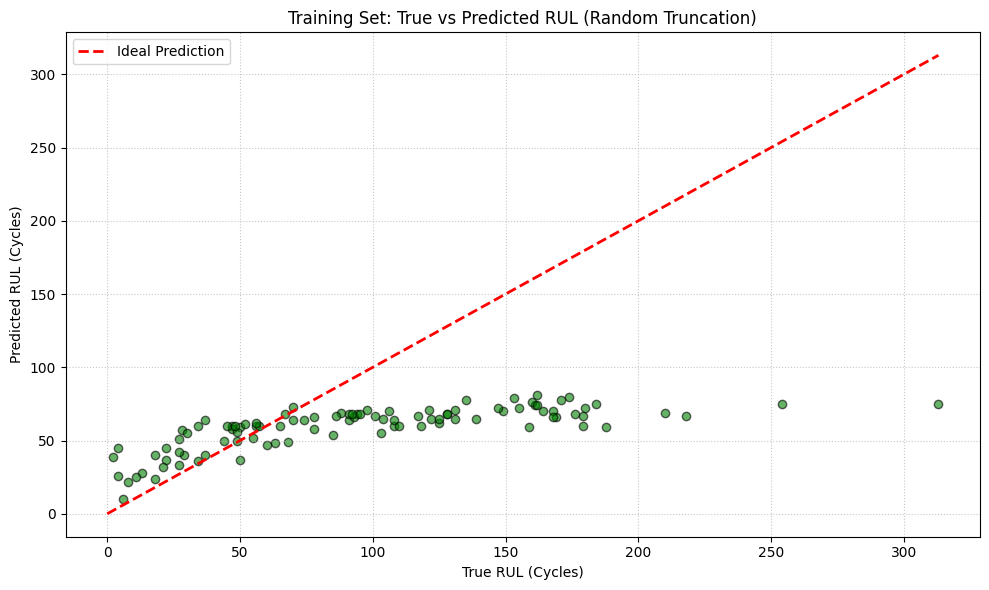

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(train_true_ruls, train_predicted_ruls, alpha=0.6, color='green', edgecolor='k')

# Plot the ideal 1:1 line
max_rul_train = max(max(train_true_ruls), max(train_predicted_ruls))
plt.plot([0, max_rul_train], [0, max_rul_train], color='red', linestyle='--', linewidth=2, label='Ideal Prediction')

plt.xlabel('True RUL (Cycles)')
plt.ylabel('Predicted RUL (Cycles)')
plt.title('Training Set: True vs Predicted RUL (Random Truncation)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()